# Temporal Graph Neural Network Architecture Study
## CAMELS-SIMBA U1000 / Top1500 / $\Omega_m$ Regression
**Notebook 16 — final temporal-study consolidation.** This presentation and reproducibility notebook asks whether five-snapshot evolution improves $\Omega_m$ regression over a final-snapshot Static GCN. It performs **no training, tuning, graph or dataset construction, inference, or model selection**. Results come only from frozen artifacts, with validation selection committed before held-out test inspection.

# 1 — Reproducibility and artifact preflight
The preflight resolves the repository, verifies frozen records and commits, loads the final tables, and checks every held-out prediction file without modifying experiment artifacts.

In [1]:
from pathlib import Path
import json,math,subprocess,warnings
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display
warnings.filterwarnings('ignore',category=FutureWarning)
def root(p=Path.cwd()):
 for q in (p,*p.parents):
  if (q/'.git').exists() and (q/'reports/temporal_five_model').is_dir(): return q
 raise RuntimeError('repository root not found')
ROOT=root(); SRC=ROOT/'reports/temporal_five_model'; REG=ROOT/'reports/experiment_registry'; OUT=ROOT/'notebooks/visualization/outputs/16_u1000_temporal_architecture_study'; OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,123,2025]; MODELS=['Static GCN','EvolveGCN-H','EvolveGCN-O','GCN-GRU','GCN-Transformer']; SHORT=['Static','Evolve-H','Evolve-O','GCN-GRU','Transformer']; PARAMS=dict(zip(MODELS,[5281,3408097,11527,11617,13825])); COLORS=dict(zip(MODELS,['#76B7B2','#E15759','#59A14F','#4C78A8','#B07AA1'])); SC={42:'#4C78A8',123:'#F28E2B',2025:'#59A14F'}
plt.rcParams.update({'figure.dpi':115,'savefig.dpi':240,'axes.spines.top':False,'axes.spines.right':False,'font.size':9.5,'axes.titleweight':'semibold'})
def figsave(fig,name): p=OUT/name; fig.savefig(p,dpi=240,bbox_inches='tight',transparent=True); plt.show(); return p
def tabsave(df,num,name): df.to_csv(OUT/f'table{num:02d}_{name}.csv',index=False); return df
inputs=['validation_seed_metrics.csv','validation_summary.csv','validation_paired_deltas.csv','validation_tables.md','test_seed_metrics.csv','test_summary.csv','test_paired_deltas.csv','test_tables.md','model_protocol_table.csv','hypothesis_summary.csv']
regs=['u1000_top1500_temporal_five_model_integrity_audit.json','u1000_top1500_temporal_five_model_validation_freeze.json','u1000_top1500_temporal_five_model_validation_report.md','u1000_top1500_temporal_five_model_postfreeze_test_evaluation.json','u1000_top1500_temporal_five_model_postfreeze_test_report.md','u1000_top1500_evolvegcn_o_training_closure.json','notebook16_temporal_architecture_outline.md']
for f in inputs: assert (SRC/f).is_file() and (SRC/f).stat().st_size
for f in regs: assert (REG/f).is_file() and (REG/f).stat().st_size
val=pd.read_csv(SRC/inputs[0]); vs=pd.read_csv(SRC/inputs[1]); vd=pd.read_csv(SRC/inputs[2]); test=pd.read_csv(SRC/inputs[4]); ts=pd.read_csv(SRC/inputs[5]); td=pd.read_csv(SRC/inputs[6]); protocol_source=pd.read_csv(SRC/inputs[8]); hypothesis_source=pd.read_csv(SRC/inputs[9])
freeze=json.loads((REG/regs[1]).read_text()); post=json.loads((REG/regs[3]).read_text())
assert len(val)==len(test)==15 and set(val.model)==set(test.model)==set(MODELS) and set(val.seed)==set(test.seed)==set(SEEDS)
assert freeze['exact_frozen_conclusion']=='ROBUST FIVE-MODEL WINNER: GCN-GRU' and not freeze['heldout_test_metrics_read_before_freeze'] and not freeze['heldout_test_metrics_used_for_selection']
assert post['validation_freeze_commit']=='4143a4a77139576ca8fb6c0866d57dd755c51caa' and not post['test_metrics_used_for_model_selection']
HEAD=subprocess.run(['git','rev-parse','HEAD'],cwd=ROOT,check=True,capture_output=True,text=True).stdout.strip(); assert subprocess.run(['git','merge-base','--is-ancestor','772f0939b2bec7913aee224b5a338c763d21f7e2',HEAD],cwd=ROOT).returncode==0
print('PASS — frozen artifact preflight at',HEAD[:12])

PASS — frozen artifact preflight at ef5fb30b974a


# 2 — Connection to Notebook 15
Notebook 15 froze U1000/Top1500, periodic kNN $k=8$, raw7, and no normalization, while showing persistent static prediction compression. The next question is whether five-snapshot evolution improves accuracy and target-distribution recovery.

# 3 — Temporal Architecture Study Roadmap

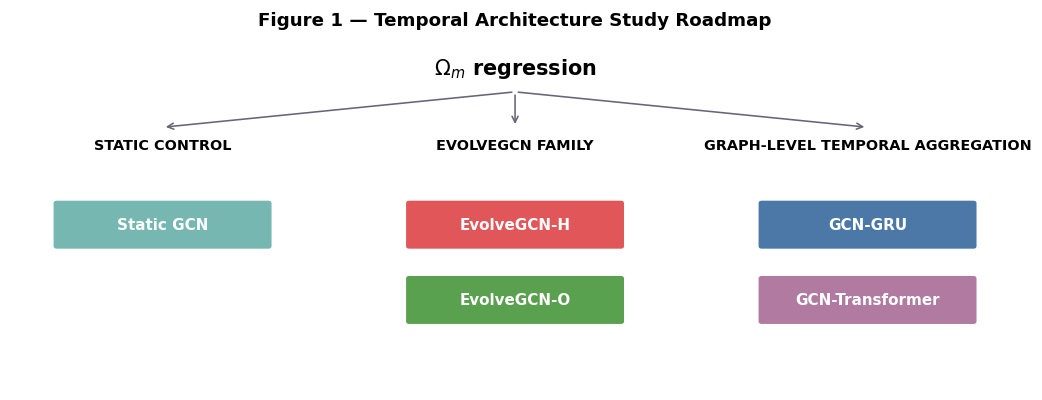

In [2]:
fig,ax=plt.subplots(figsize=(11.3,4)); ax.set(xlim=(0,10),ylim=(0,4)); ax.axis('off'); ax.text(5,3.55,r'$\Omega_m$ regression',ha='center',fontsize=13,weight='bold')
for title,x,mods in [('STATIC CONTROL',1.5,['Static GCN']),('EVOLVEGCN FAMILY',5,['EvolveGCN-H','EvolveGCN-O']),('GRAPH-LEVEL TEMPORAL AGGREGATION',8.5,['GCN-GRU','GCN-Transformer'])]:
 ax.annotate('',(x,2.95),(5,3.35),arrowprops={'arrowstyle':'->','color':'#667'}); ax.text(x,2.7,title,ha='center',fontsize=9,weight='bold')
 for j,m in enumerate(mods):
  y=1.85-.85*j; ax.add_patch(FancyBboxPatch((x-1.05,y-.24),2.1,.48,boxstyle='round,pad=.04',facecolor=COLORS[m],edgecolor='white')); ax.text(x,y,m,ha='center',va='center',color='white',weight='bold')
ax.set_title('Figure 1 — Temporal Architecture Study Roadmap'); fig01=figsave(fig,'fig01_temporal_architecture_roadmap.png')

# 4 — Frozen protocol

In [3]:
table01=pd.DataFrame([['Dataset','CAMELS-SIMBA'],['Universes','1,000'],['Halo selection','Top1500'],['Graph','periodic sparse kNN'],['k / box',r'8 / 25 $h^{-1}$ Mpc'],['Snapshots / scale factors','5 / 0.2, 0.25, 0.51209, 0.75065, 1.0'],['Features','log10(Mvir), X, Y, Z, VX, VY, VZ'],['Normalization','none'],['Target',r'$\Omega_m$'],['Split','700 train / 99 validation / 201 test'],['Seeds','42, 123, 2025'],['Selection metric','Validation MAE']],columns=['Setting','Frozen value']); tabsave(table01,1,'frozen_protocol'); display(table01.style.hide(axis='index'))

Setting,Frozen value
Dataset,CAMELS-SIMBA
Universes,"1,000"
Halo selection,Top1500
Graph,periodic sparse kNN
k / box,8 / 25 $h^{-1}$ Mpc
Snapshots / scale factors,"5 / 0.2, 0.25, 0.51209, 0.75065, 1.0"
Features,"log10(Mvir), X, Y, Z, VX, VY, VZ"
Normalization,none
Target,$\Omega_m$
Split,700 train / 99 validation / 201 test


# 5 — Architecture and fairness
The all-five comparison is a **matched-data / matched-split architecture benchmark**, not a parameter-matched ablation. GRU versus Transformer is tightest; H versus O is a controlled family comparison with inherent formulation and substantial capacity differences.

In [4]:
table02=pd.DataFrame([['Static GCN','Static control','1 (final)','None','3-layer GCN','Mean','—','Final-snapshot control'],['EvolveGCN-H','EvolveGCN family','5','H weight evolution','Evolving GCN-H','Mean','Temporal mean','Existing formulation'],['EvolveGCN-O','EvolveGCN family','5','O weight evolution','Evolving GCN-O','Mean','Temporal mean','Alternative formulation'],['GCN-GRU','Graph-level temporal aggregation','5','GRU recurrence','Shared 3-layer GCN','Mean','Final hidden state','Recurrent aggregation'],['GCN-Transformer','Graph-level temporal aggregation','5','Self-attention','Shared 3-layer GCN','Mean','Final token','Self-attention aggregation']],columns=['Model','Family','Snapshots','Temporal mechanism','Spatial mechanism','Graph pooling','Temporal readout','Scientific role']); table02.insert(7,'Parameters',[f'{PARAMS[m]:,}' for m in MODELS]); tabsave(table02,2,'architecture_fairness'); display(table02.style.hide(axis='index'))

Model,Family,Snapshots,Temporal mechanism,Spatial mechanism,Graph pooling,Temporal readout,Parameters,Scientific role
Static GCN,Static control,1 (final),None,3-layer GCN,Mean,—,"5,281",Final-snapshot control
EvolveGCN-H,EvolveGCN family,5,H weight evolution,Evolving GCN-H,Mean,Temporal mean,"3,408,097",Existing formulation
EvolveGCN-O,EvolveGCN family,5,O weight evolution,Evolving GCN-O,Mean,Temporal mean,"11,527",Alternative formulation
GCN-GRU,Graph-level temporal aggregation,5,GRU recurrence,Shared 3-layer GCN,Mean,Final hidden state,"11,617",Recurrent aggregation
GCN-Transformer,Graph-level temporal aggregation,5,Self-attention,Shared 3-layer GCN,Mean,Final token,"13,825",Self-attention aggregation


# 6 — Model-selection firewall
> **MODEL SELECTION PROTOCOL**
>
> Selection used **validation MAE only**. Test metrics were locked until the validation conclusion was serialized and committed.
>
> Freeze commit: `4143a4a77139576ca8fb6c0866d57dd755c51caa`
>
> Test read before freeze: **NO**. Test used for selection: **NO**.

# 7 — Q1/Q5: Validation MAE across architectures

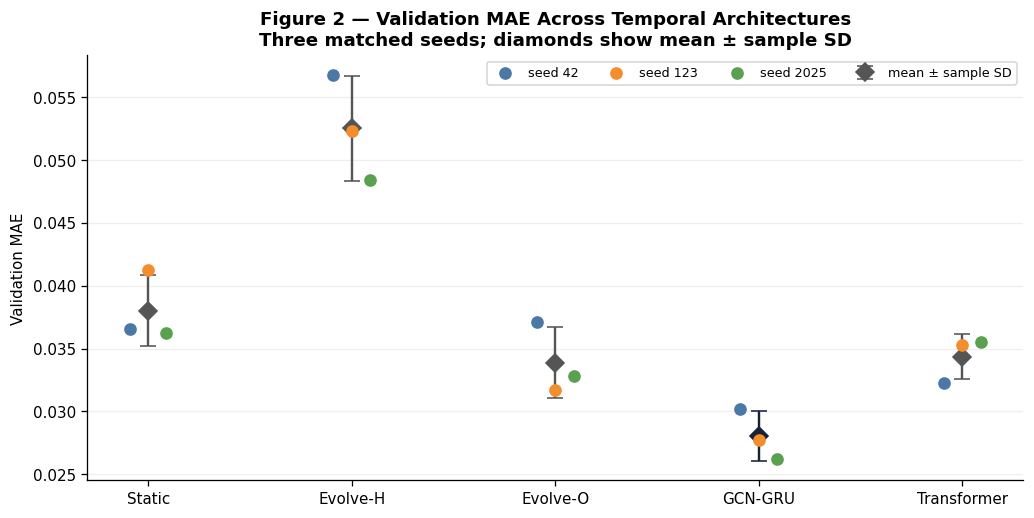

In [5]:
def headline(frame,summ,title,ylabel,name):
 fig,ax=plt.subplots(figsize=(10.5,4.8)); x=np.arange(5)
 for i,m in enumerate(MODELS):
  q=frame.query('model==@m')
  for j,s in zip([-.09,0,.09],SEEDS): ax.scatter(i+j,q.query('seed==@s').mae,s=48,c=SC[s],label=f'seed {s}' if i==0 else None,zorder=3)
  z=summ.query('model==@m').iloc[0]; ax.errorbar(i,z.mae_mean,yerr=z.mae_sample_sd,fmt='D',ms=8,c='#152238' if m=='GCN-GRU' else '#555',capsize=5,label='mean ± sample SD' if i==0 else None)
 ax.set_xticks(x,SHORT); ax.set_ylabel(ylabel); ax.legend(ncol=4,fontsize=8); ax.grid(axis='y',alpha=.2); ax.set_title(title); return figsave(fig,name)
fig02=headline(val,vs,'Figure 2 — Validation MAE Across Temporal Architectures\nThree matched seeds; diamonds show mean ± sample SD','Validation MAE','fig02_validation_mae.png')

# 8 — Validation aggregate table

In [6]:
def fmt_table(summ,test_mode=False):
 out=[]
 for m in MODELS:
  q=summ.query('model==@m').iloc[0]; out.append([m,f'{PARAMS[m]:,}',f'{q.mae_mean:.5f} ± {q.mae_sample_sd:.5f}',f'{q.rmse_mean:.5f} ± {q.rmse_sample_sd:.5f}',f'{q.r2_mean:.5f} ± {q.r2_sample_sd:.5f}',f'{q.sd_ratio_mean:.5f}',f'{q.calibration_slope_mean:.5f}',f'{q.pearson_r_mean:.5f}'])
 return pd.DataFrame(out,columns=['Model','Parameters','MAE mean ± SD','RMSE mean ± SD','R² mean ± SD','SD ratio','Slope','Pearson r'])
table03=fmt_table(vs); tabsave(table03,3,'validation_aggregate'); display(table03.style.apply(lambda r:['font-weight:bold;background-color:#E8F0FA' if r.Model=='GCN-GRU' else '' for _ in r],axis=1).hide(axis='index'))

Model,Parameters,MAE mean ± SD,RMSE mean ± SD,R² mean ± SD,SD ratio,Slope,Pearson r
Static GCN,"5,281",0.03802 ± 0.00281,0.04841 ± 0.00236,0.82425 ± 0.02425,0.87327,0.79442,0.90966
EvolveGCN-H,"3,408,097",0.05252 ± 0.00417,0.06354 ± 0.00389,0.69647 ± 0.05194,0.85542,0.71695,0.83736
EvolveGCN-O,"11,527",0.03389 ± 0.00285,0.04303 ± 0.00378,0.86054 ± 0.02921,0.93360,0.86933,0.93070
GCN-GRU,"11,617",0.02806 ± 0.00200,0.03572 ± 0.00218,0.90401 ± 0.01715,0.91969,0.87612,0.95254
GCN-Transformer,"13,825",0.03437 ± 0.00180,0.04212 ± 0.00193,0.86774 ± 0.00516,0.84725,0.79445,0.93800


# 9 — Q1: Temporal MAE change relative to Static

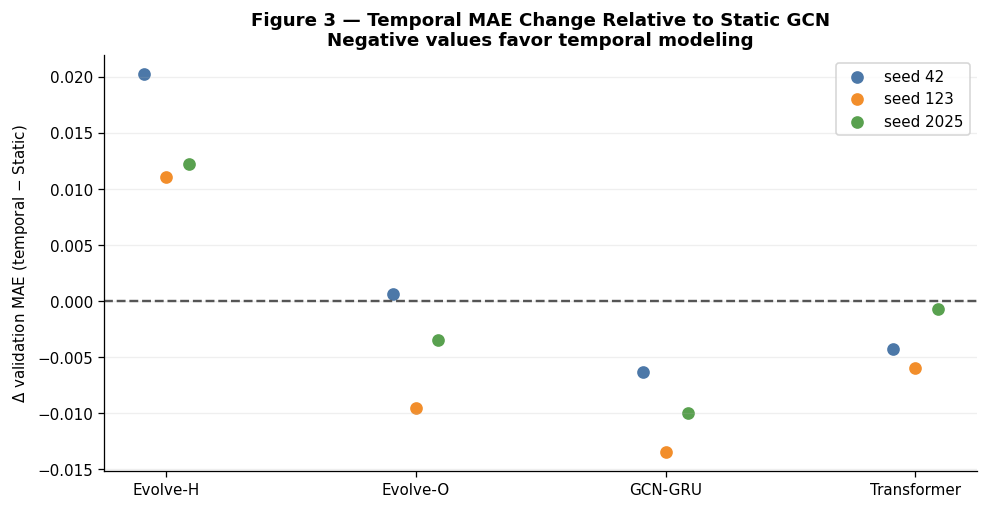

comparison,seed,reference_mae,first_model_mae,delta_mae,delta_percent_of_reference
EvolveGCN-H - Static GCN,42,0.036552,0.056782,0.020230,55.346149
EvolveGCN-H - Static GCN,123,0.041268,0.052325,0.011057,26.793242
EvolveGCN-H - Static GCN,2025,0.036248,0.048440,0.012192,33.635187
EvolveGCN-O - Static GCN,42,0.036552,0.037125,0.000573,1.566916
EvolveGCN-O - Static GCN,123,0.041268,0.031740,-0.009527,-23.086765
EvolveGCN-O - Static GCN,2025,0.036248,0.032799,-0.003449,-9.514768
GCN-GRU - Static GCN,42,0.036552,0.030202,-0.006350,-17.371758
GCN-GRU - Static GCN,123,0.041268,0.027756,-0.013511,-32.740442
GCN-GRU - Static GCN,2025,0.036248,0.026236,-0.010012,-27.620731
GCN-Transformer - Static GCN,42,0.036552,0.032294,-0.004258,-11.648240


In [7]:
names=MODELS[1:]; fig,ax=plt.subplots(figsize=(9.8,4.7))
for i,m in enumerate(names):
 q=vd.query('comparison==@m+" - Static GCN"')
 for j,s in zip([-.09,0,.09],SEEDS): ax.scatter(i+j,q.query('seed==@s').delta_mae,s=48,c=SC[s],label=f'seed {s}' if i==0 else None)
ax.axhline(0,c='#555',ls='--'); ax.set_xticks(range(4),SHORT[1:]); ax.set_ylabel(r'$\Delta$ validation MAE (temporal − Static)'); ax.legend(); ax.grid(axis='y',alpha=.2); ax.set_title('Figure 3 — Temporal MAE Change Relative to Static GCN\nNegative values favor temporal modeling'); fig03=figsave(fig,'fig03_temporal_delta_vs_static.png')
table04=vd.copy(); tabsave(table04,4,'validation_paired'); display(table04.style.hide(axis='index'))

# 10 — Q2: EvolveGCN-H versus EvolveGCN-O
O improves over H at all three validation seeds: H is not representative of the whole EvolveGCN family. The models are not parameter matched.

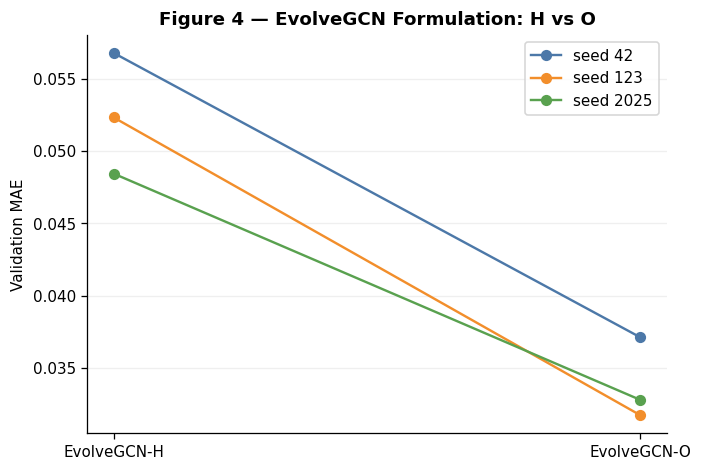

In [8]:
def paired(a,b,title,name):
 fig,ax=plt.subplots(figsize=(6.5,4.5))
 for s in SEEDS: ax.plot([0,1],[val.query('model==@a and seed==@s').mae.iloc[0],val.query('model==@b and seed==@s').mae.iloc[0]],'-o',c=SC[s],label=f'seed {s}')
 ax.set_xticks([0,1],[a,b]); ax.set_ylabel('Validation MAE'); ax.legend(); ax.grid(axis='y',alpha=.2); ax.set_title(title); return figsave(fig,name)
fig04=paired('EvolveGCN-H','EvolveGCN-O','Figure 4 — EvolveGCN Formulation: H vs O','fig04_evolvegcn_h_vs_o.png')

# 11 — Q4: Recurrent versus self-attention aggregation
This strongest comparison matches encoder, pooling, data, splits, seeds, budget, optimizer, scheduler, stopping, and clipping; the main change is temporal aggregation.

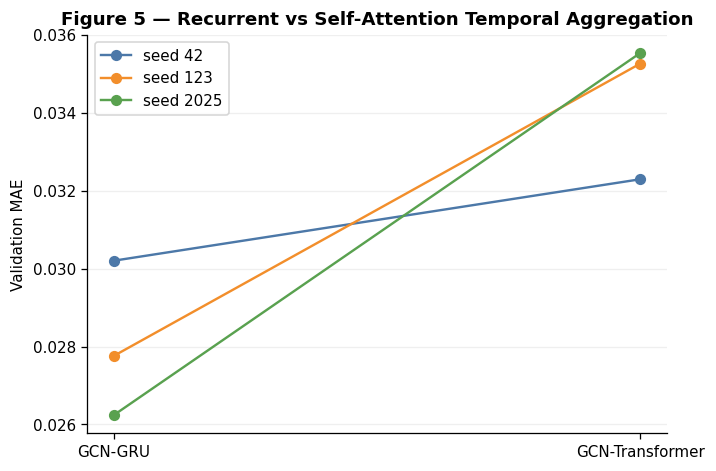

In [9]:
fig05=paired('GCN-GRU','GCN-Transformer','Figure 5 — Recurrent vs Self-Attention Temporal Aggregation','fig05_gru_vs_transformer.png')

# 12 — Q7: Validation prediction compression

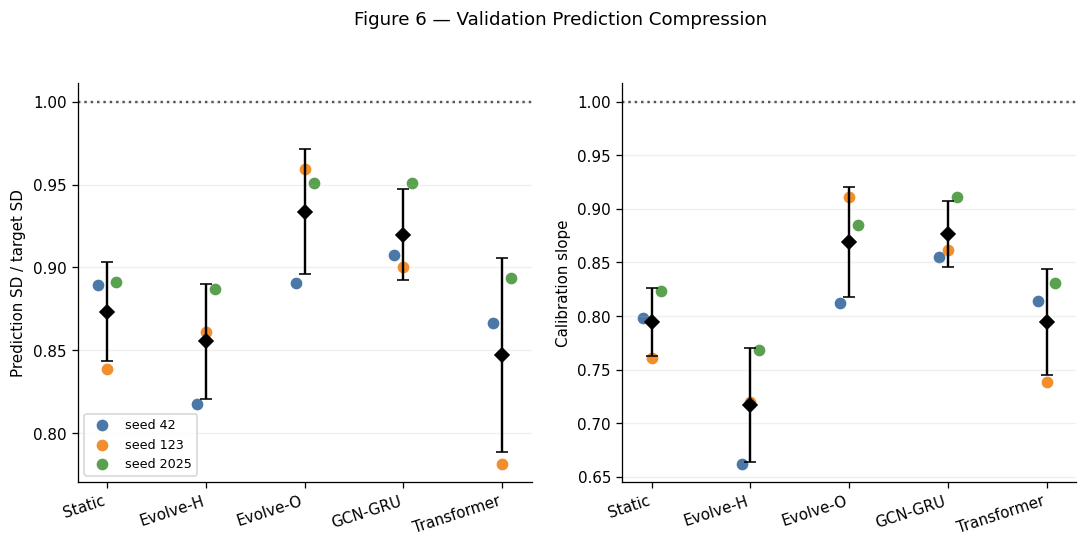

In [10]:
def compression(frame,title,name):
 fig,axes=plt.subplots(1,2,figsize=(11.2,4.5)); x=np.arange(5)
 for ax,k,label in zip(axes,['sd_ratio','calibration_slope'],['Prediction SD / target SD','Calibration slope']):
  for i,m in enumerate(MODELS):
   q=frame.query('model==@m')
   for j,s in zip([-.09,0,.09],SEEDS): ax.scatter(i+j,q.query('seed==@s')[k],s=40,c=SC[s],label=f'seed {s}' if i==0 else None)
   ax.errorbar(i,q[k].mean(),yerr=q[k].std(ddof=1),fmt='Dk',capsize=4)
  ax.axhline(1,c='#555',ls=':'); ax.set_xticks(x,SHORT,rotation=18,ha='right'); ax.set_ylabel(label); ax.grid(axis='y',alpha=.2)
 axes[0].legend(fontsize=8); fig.suptitle(title,y=1.02); return figsave(fig,name)
fig06=compression(val,'Figure 6 — Validation Prediction Compression','fig06_validation_compression.png')

GRU and O recover more target variation than Static across the combined diagnostics. Compression improves but is not eliminated.

# 13 — Model capacity versus validation MAE

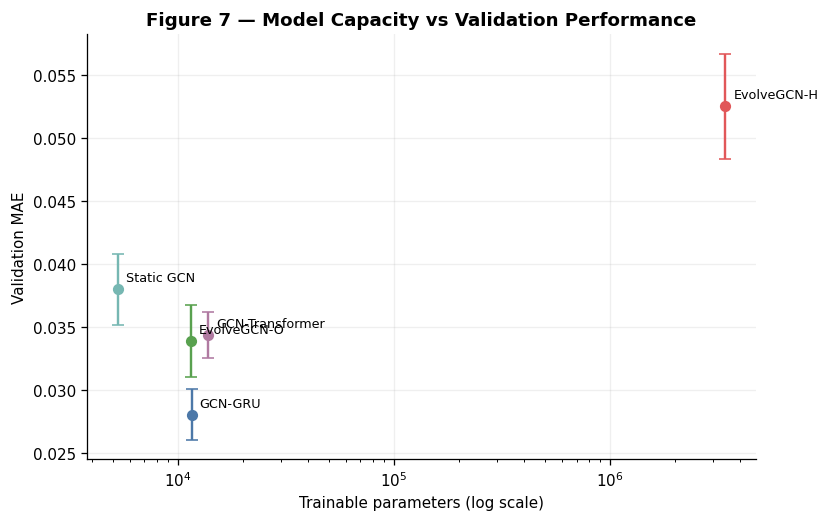

In [11]:
fig,ax=plt.subplots(figsize=(7.5,4.8))
for _,q in vs.iterrows(): ax.errorbar(q.parameters,q.mae_mean,yerr=q.mae_sample_sd,fmt='o',c=COLORS[q.model],capsize=4); ax.annotate(q.model,(q.parameters,q.mae_mean),xytext=(5,5),textcoords='offset points',fontsize=8)
ax.set_xscale('log'); ax.set(xlabel='Trainable parameters (log scale)',ylabel='Validation MAE',title='Figure 7 — Model Capacity vs Validation Performance'); ax.grid(alpha=.2); fig07=figsave(fig,'fig07_capacity_vs_validation_mae.png')

This is descriptive only and does not establish that capacity causes performance.

# 14 — Frozen validation decision
> ## FROZEN VALIDATION CONCLUSION
> **ROBUST FIVE-MODEL WINNER: GCN-GRU**
>
> Lowest validation MAE for seeds 42, 123, and 2025; mean **0.02806 ± 0.00200**.

Ranking: **1 GCN-GRU; 2 EvolveGCN-O; 3 GCN-Transformer; 4 Static GCN; 5 EvolveGCN-H.** Held-out test metrics were not used for this decision.

# 15 — Held-out test unlock
The architecture decision is now frozen. Test data are introduced only to evaluate generalization and cannot revise selection.

# 16 — Q6: Held-out test MAE

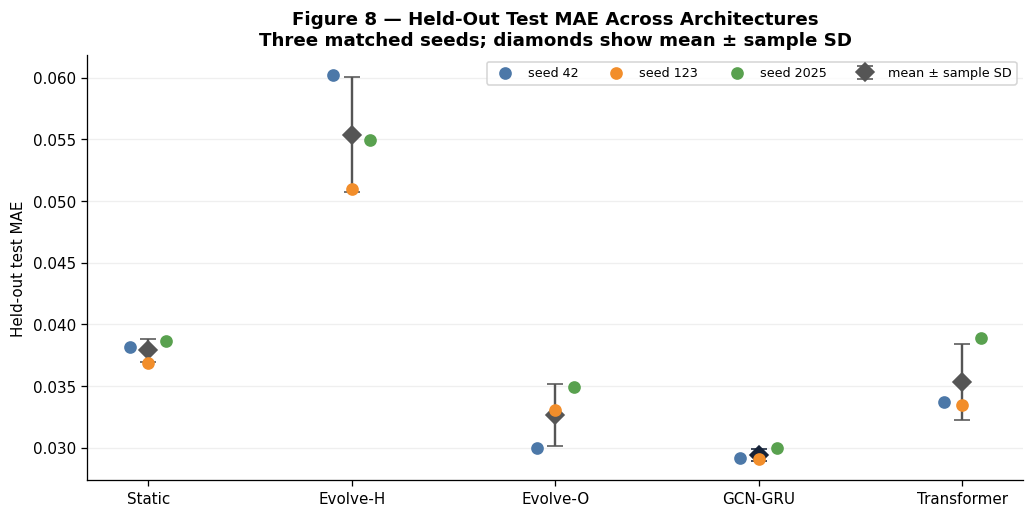

Model,Parameters,MAE mean ± SD,RMSE mean ± SD,R² mean ± SD,SD ratio,Slope,Pearson r
Static GCN,"5,281",0.03789 ± 0.00094,0.04935 ± 0.00062,0.82632 ± 0.01057,0.87090,0.79359,0.91111
EvolveGCN-H,"3,408,097",0.05539 ± 0.00465,0.08474 ± 0.02751,0.46218 ± 0.33243,0.93266,0.67863,0.74334
EvolveGCN-O,"11,527",0.03264 ± 0.00251,0.04158 ± 0.00223,0.87612 ± 0.01869,0.94518,0.89021,0.94179
GCN-GRU,"11,617",0.02939 ± 0.00048,0.03751 ± 0.00166,0.89970 ± 0.00740,0.93288,0.88636,0.95009
GCN-Transformer,"13,825",0.03534 ± 0.00309,0.04359 ± 0.00540,0.86392 ± 0.03020,0.84114,0.78749,0.93674


In [12]:
fig08=headline(test,ts,'Figure 8 — Held-Out Test MAE Across Architectures\nThree matched seeds; diamonds show mean ± sample SD','Held-out test MAE','fig08_test_mae.png'); table05=fmt_table(ts); tabsave(table05,5,'test_aggregate'); display(table05.style.hide(axis='index'))

# 17 — Final five-model MAE summary

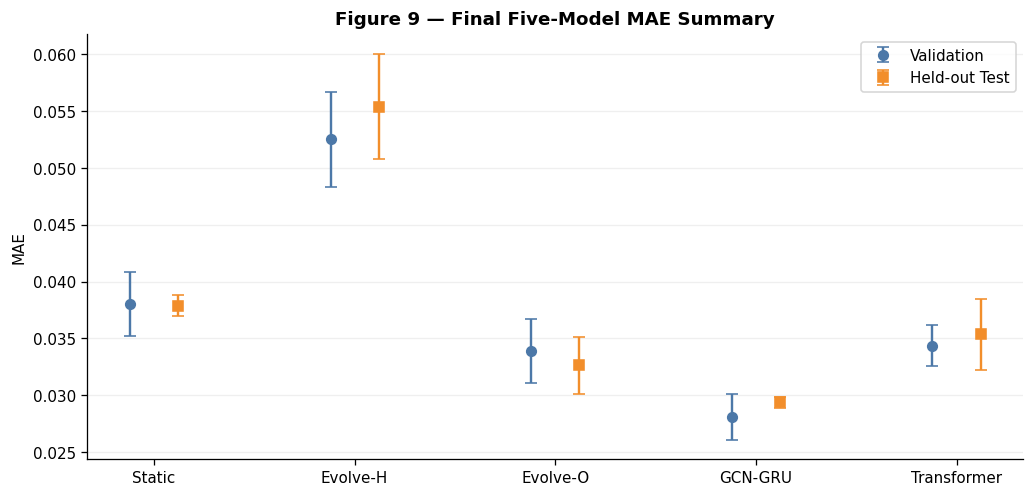

In [13]:
fig,ax=plt.subplots(figsize=(10.5,4.8)); x=np.arange(5)
for off,z,label,col,mark in [(-.12,vs,'Validation','#4C78A8','o'),(.12,ts,'Held-out Test','#F28E2B','s')]: q=z.set_index('model').loc[MODELS]; ax.errorbar(x+off,q.mae_mean,yerr=q.mae_sample_sd,fmt=mark,c=col,capsize=4,label=label)
ax.set_xticks(x,SHORT); ax.set_ylabel('MAE'); ax.legend(); ax.grid(axis='y',alpha=.2); ax.set_title('Figure 9 — Final Five-Model MAE Summary'); fig09=figsave(fig,'fig09_final_mae_summary.png')

# 18 — Final all-model table

In [14]:
interp=['Final-snapshot control','Robust degradation','Substantially improved EvolveGCN formulation','Selected temporal architecture / robust winner','Less consistent over Static; worse than GRU']; rows=[]
for m,x in zip(MODELS,interp): v=vs.query('model==@m').iloc[0]; t=ts.query('model==@m').iloc[0]; rows.append([m,f'{PARAMS[m]:,}',f'{v.mae_mean:.5f} ± {v.mae_sample_sd:.5f}',f'{t.mae_mean:.5f} ± {t.mae_sample_sd:.5f}',f'{t.r2_mean:.5f}',f'{t.sd_ratio_mean:.5f}',f'{t.calibration_slope_mean:.5f}',x])
table06=pd.DataFrame(rows,columns=['Model','Parameters','Validation MAE','Test MAE','Test R²','Test SD ratio','Test slope','Interpretation']); tabsave(table06,6,'final_comparison'); display(table06.style.hide(axis='index'))

Model,Parameters,Validation MAE,Test MAE,Test R²,Test SD ratio,Test slope,Interpretation
Static GCN,"5,281",0.03802 ± 0.00281,0.03789 ± 0.00094,0.82632,0.87090,0.79359,Final-snapshot control
EvolveGCN-H,"3,408,097",0.05252 ± 0.00417,0.05539 ± 0.00465,0.46218,0.93266,0.67863,Robust degradation
EvolveGCN-O,"11,527",0.03389 ± 0.00285,0.03264 ± 0.00251,0.87612,0.94518,0.89021,Substantially improved EvolveGCN formulation
GCN-GRU,"11,617",0.02806 ± 0.00200,0.02939 ± 0.00048,0.89970,0.93288,0.88636,Selected temporal architecture / robust winner
GCN-Transformer,"13,825",0.03437 ± 0.00180,0.03534 ± 0.00309,0.86392,0.84114,0.78749,Less consistent over Static; worse than GRU


# 19 — True versus predicted $\Omega_m$
Seed 42 is the predefined common visualization seed and **was not selected based on performance**. Each panel shows all 201 held-out universes with common limits, identity and calibration lines, and MAE/$R^2$/slope annotations. Three-seed model supplements are also saved.

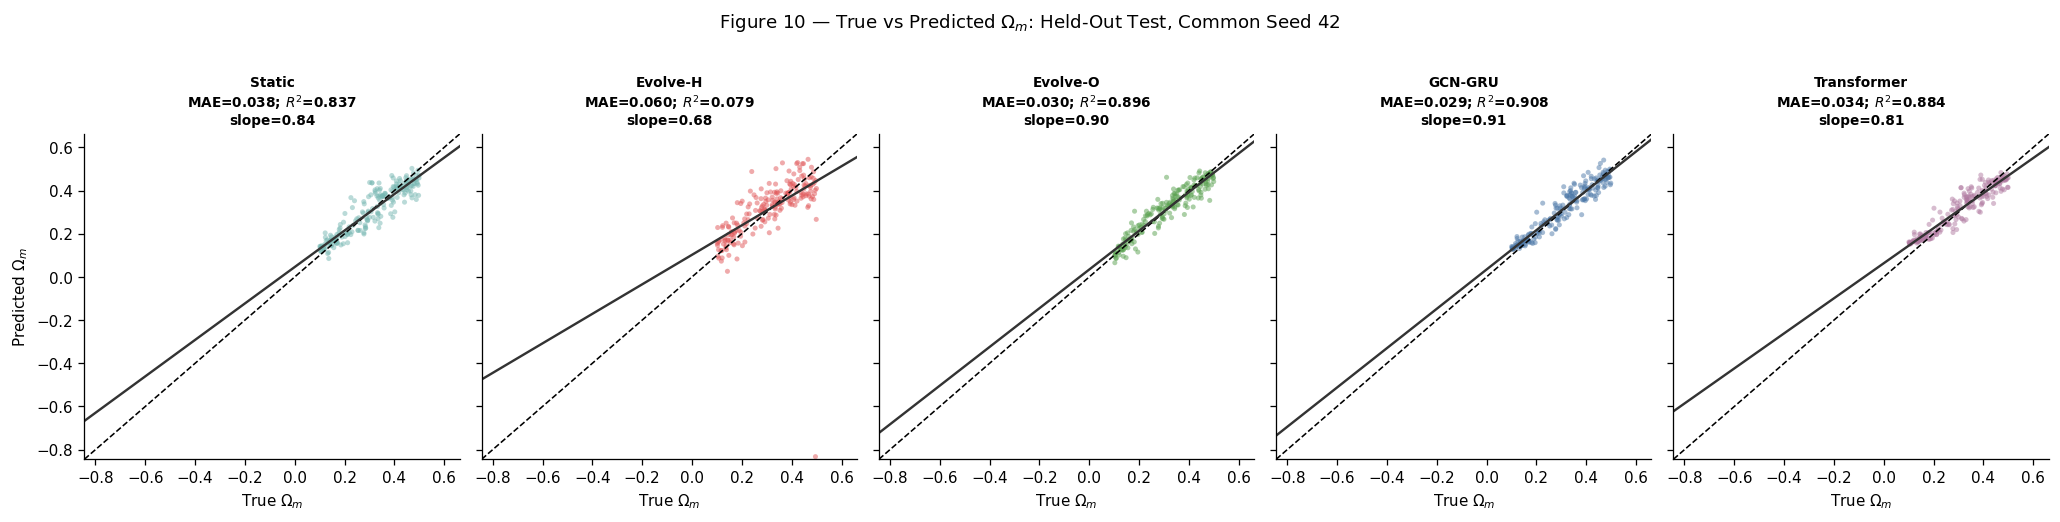

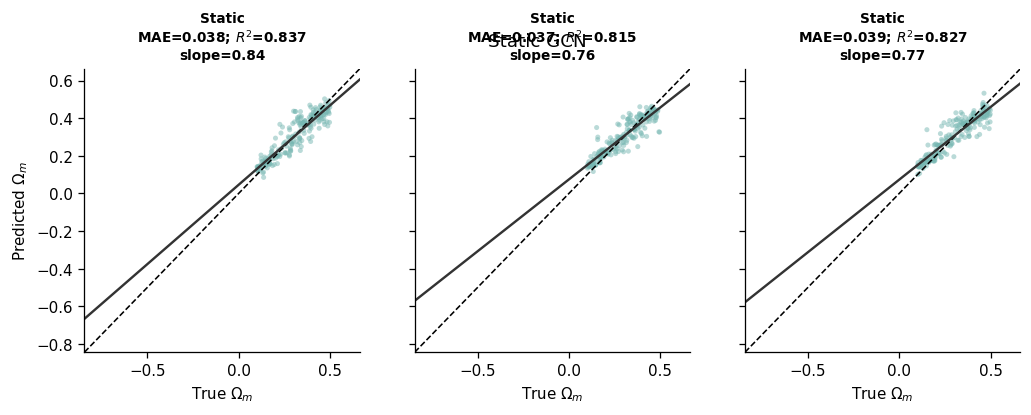

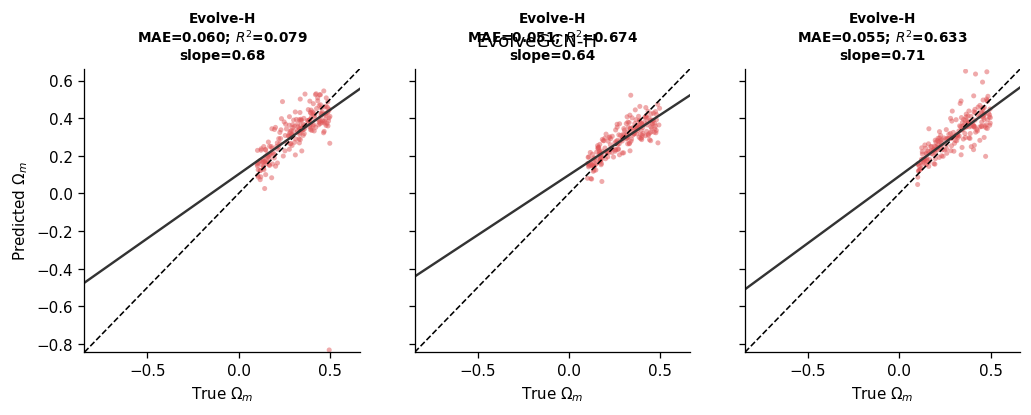

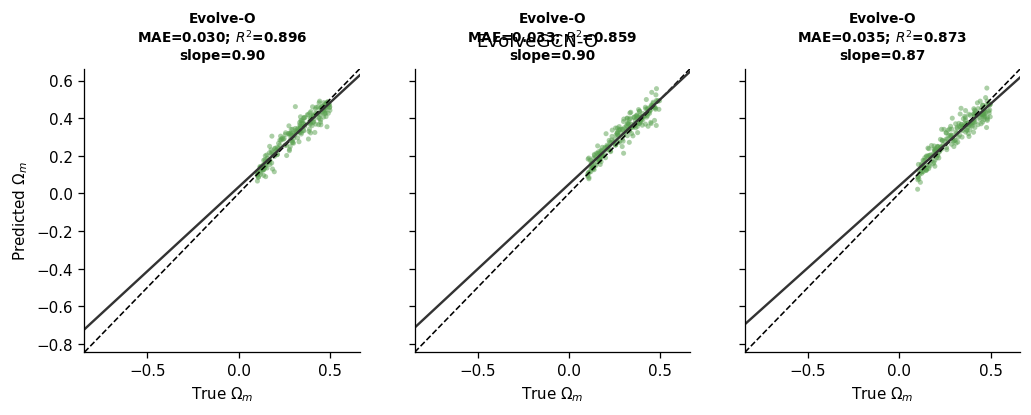

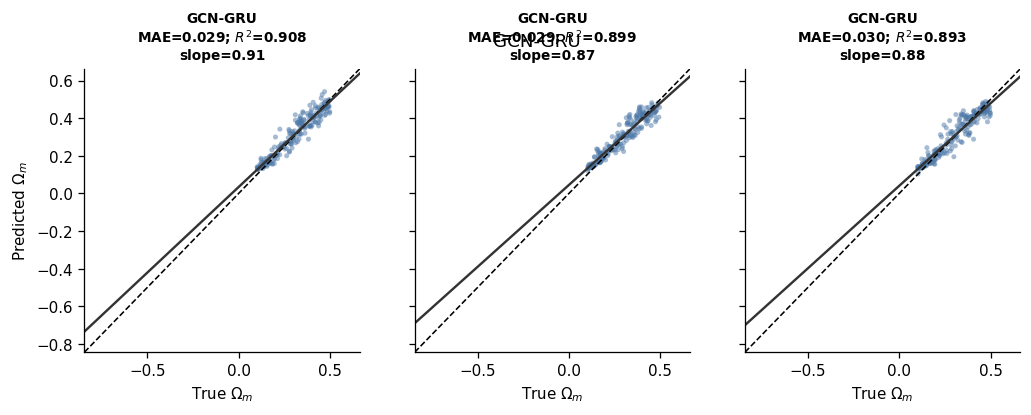

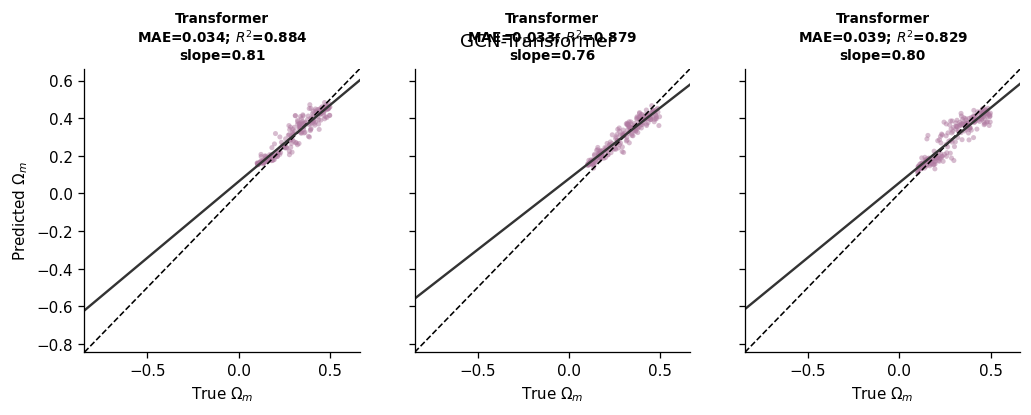

In [15]:
PAT={'Static GCN':'static_gcn_u1000_top1500_sparse_train700_seed{seed}_none_h32_l3_mean_mlp_final','EvolveGCN-H':'evolvegcn_h_u1000_top1500_sparse_train700_seed{seed}_none_h32_l2_mean_temporal_mean_linear','EvolveGCN-O':'evolvegcn_o_u1000_top1500_sparse_train700_seed{seed}_none_h32_l2_mean_temporal_mean_linear','GCN-GRU':'gcn_gru_u1000_top1500_sparse_train700_seed{seed}_none_h32_l3_final','GCN-Transformer':'gcn_temporal_transformer_u1000_top1500_sparse_train700_seed{seed}_none_h32_l3_final'}
def rp(m,s): return (Path('/home/ml/thesis-camels/experiments') if m in MODELS[:2] else ROOT/'experiments')/PAT[m].format(seed=s)
frames={}
for m in MODELS:
 for s in SEEDS:
  f=pd.read_csv(rp(m,s)/'predictions/test_predictions.csv').rename(columns={'target':'true','prediction':'pred','true_omega_m':'true','pred_omega_m':'pred'}); assert len(f)==201 and f.universe_id.is_unique and np.isfinite(f[['true','pred']]).all().all(); frames[m,s]=f
allv=np.concatenate([f[['true','pred']].values.ravel() for f in frames.values()]); lo,hi=allv.min()-.012,allv.max()+.012
def parity(m,s,ax):
 f=frames[m,s]; q=test.query('model==@m and seed==@s').iloc[0]; xx=np.array([lo,hi]); ax.scatter(f.true,f.pred,s=10,alpha=.5,c=COLORS[m],edgecolors='none'); ax.plot(xx,xx,'k--',lw=1); ax.plot(xx,q.calibration_intercept+q.calibration_slope*xx,c='#333'); ax.set(xlim=(lo,hi),ylim=(lo,hi),xlabel=r'True $\Omega_m$'); ax.set_title(f'{SHORT[MODELS.index(m)]}\nMAE={q.mae:.3f}; $R^2$={q.r2:.3f}\nslope={q.calibration_slope:.2f}',fontsize=8.5)
fig,axes=plt.subplots(1,5,figsize=(18,4.4),sharex=True,sharey=True)
for ax,m in zip(axes,MODELS): parity(m,42,ax)
axes[0].set_ylabel(r'Predicted $\Omega_m$'); fig.suptitle(r'Figure 10 — True vs Predicted $\Omega_m$: Held-Out Test, Common Seed 42',y=1.02); fig.tight_layout(); fig10=figsave(fig,'fig10_true_vs_predicted_seed42.png')
for m in MODELS:
 fig,axes=plt.subplots(1,3,figsize=(10.5,3.2),sharex=True,sharey=True)
 for ax,s in zip(axes,SEEDS): parity(m,s,ax)
 axes[0].set_ylabel(r'Predicted $\Omega_m$'); fig.suptitle(m); figsave(fig,'supp_true_'+m.lower().replace(' ','_').replace('-','_')+'.png')

# 20 — Residual structure
Residual is $\hat\Omega_m-\Omega_m$. Raw points and equal-width binned means expose central regression and possible heteroscedasticity without assigning causality from visual patterns.

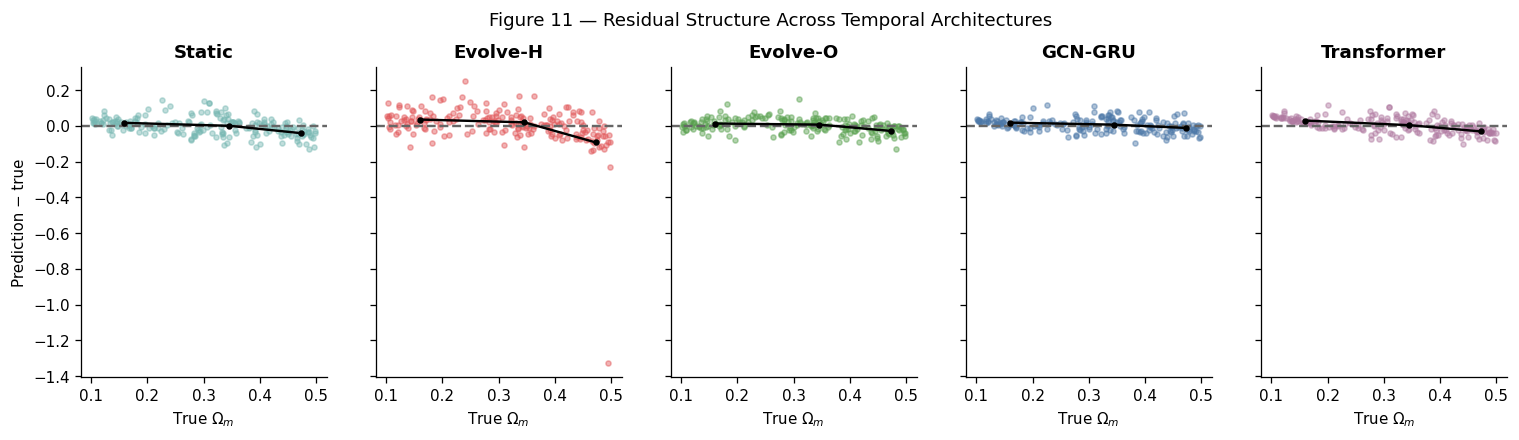

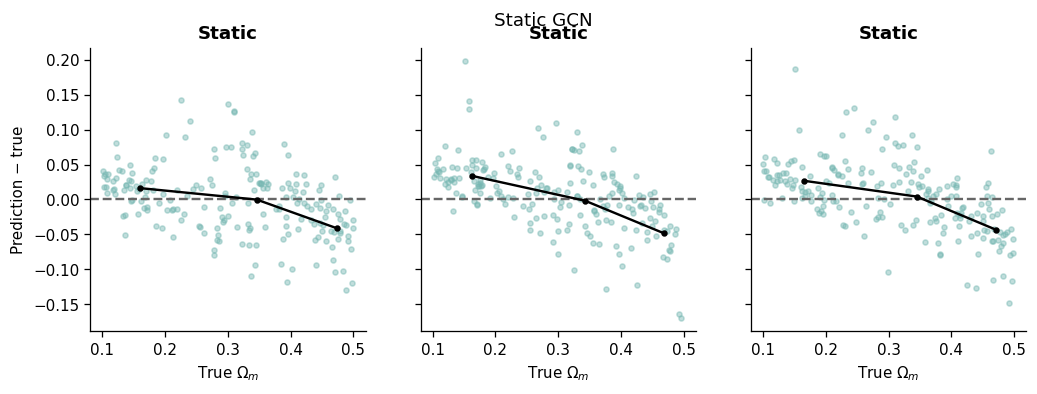

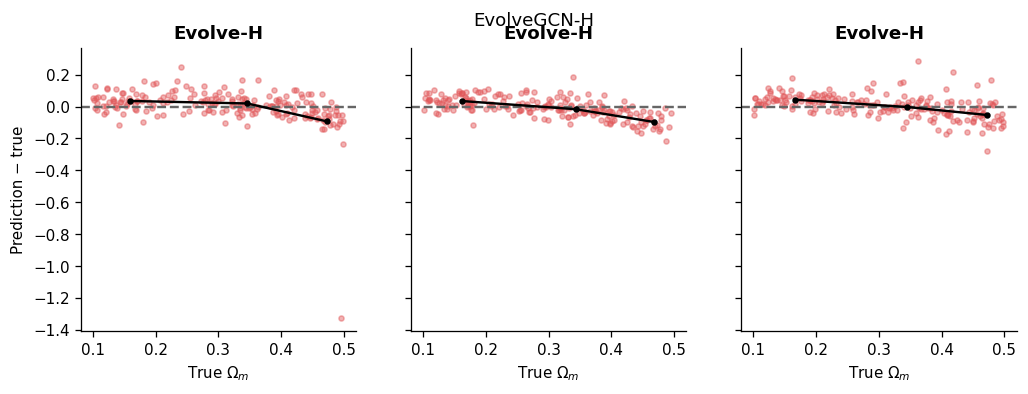

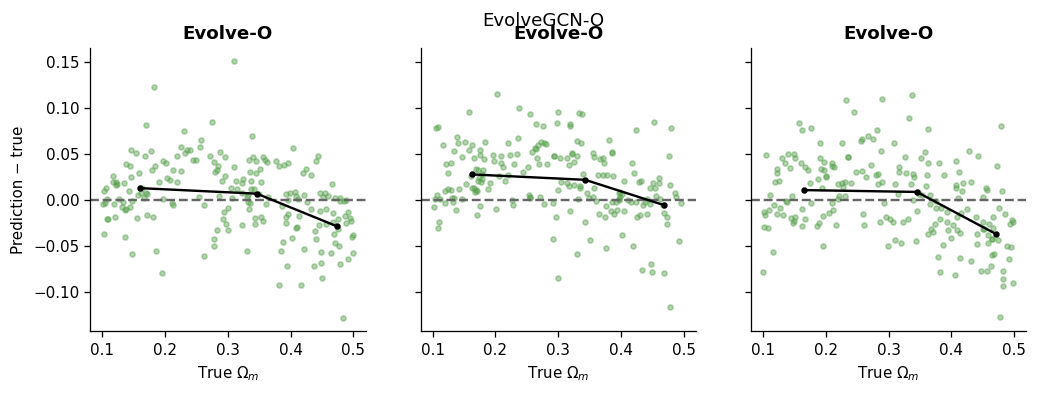

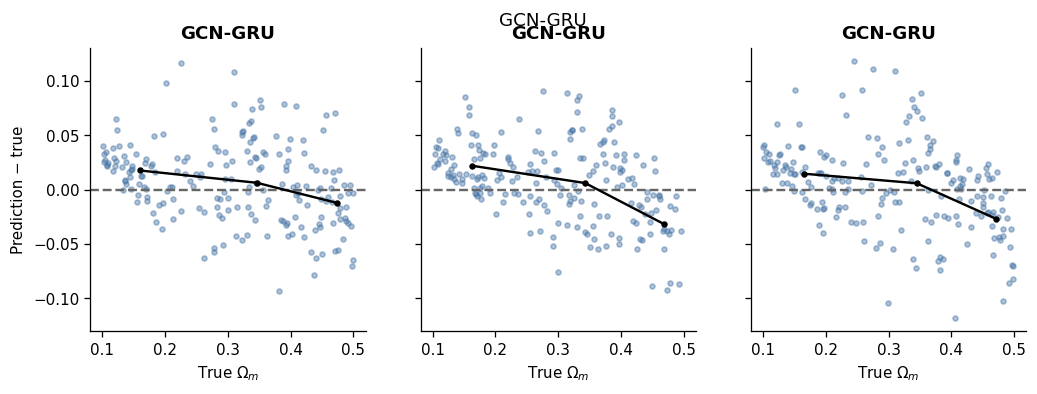

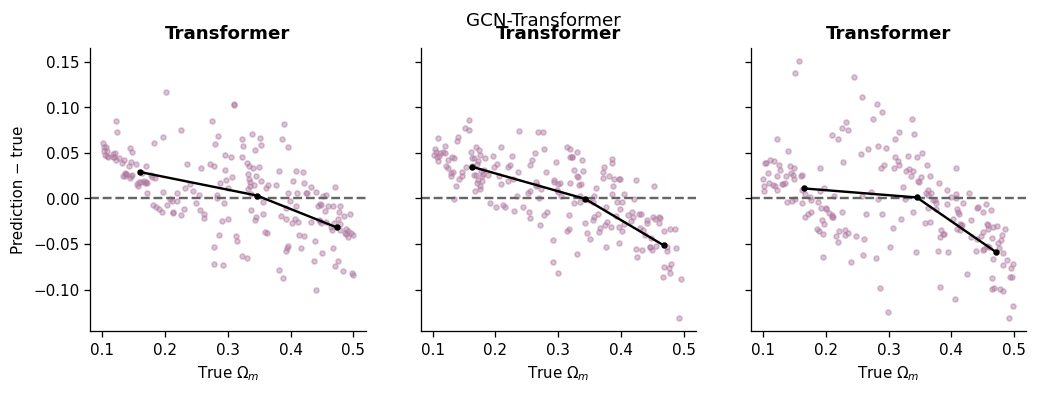

In [16]:
def residual(m,s,ax):
 f=frames[m,s].copy(); f['r']=f.pred-f.true; ax.scatter(f.true,f.r,s=10,alpha=.45,c=COLORS[m]); ax.axhline(0,c='#666',ls='--'); f['bin']=pd.cut(f.true,np.linspace(lo,hi,8),include_lowest=True); g=f.groupby('bin',observed=True).agg(x=('true','mean'),r=('r','mean')).dropna(); ax.plot(g.x,g.r,'o-',c='black',ms=3); ax.set(title=SHORT[MODELS.index(m)],xlabel=r'True $\Omega_m$')
fig,axes=plt.subplots(1,5,figsize=(16,3.5),sharex=True,sharey=True)
for ax,m in zip(axes,MODELS): residual(m,42,ax)
axes[0].set_ylabel('Prediction − true'); fig.suptitle('Figure 11 — Residual Structure Across Temporal Architectures',y=1.02); fig11=figsave(fig,'fig11_residuals_seed42.png')
for m in MODELS:
 fig,axes=plt.subplots(1,3,figsize=(10.5,3.2),sharex=True,sharey=True)
 for ax,s in zip(axes,SEEDS): residual(m,s,ax)
 axes[0].set_ylabel('Prediction − true'); fig.suptitle(m); figsave(fig,'supp_residual_'+m.lower().replace(' ','_').replace('-','_')+'.png')

# 21 — Test prediction compression

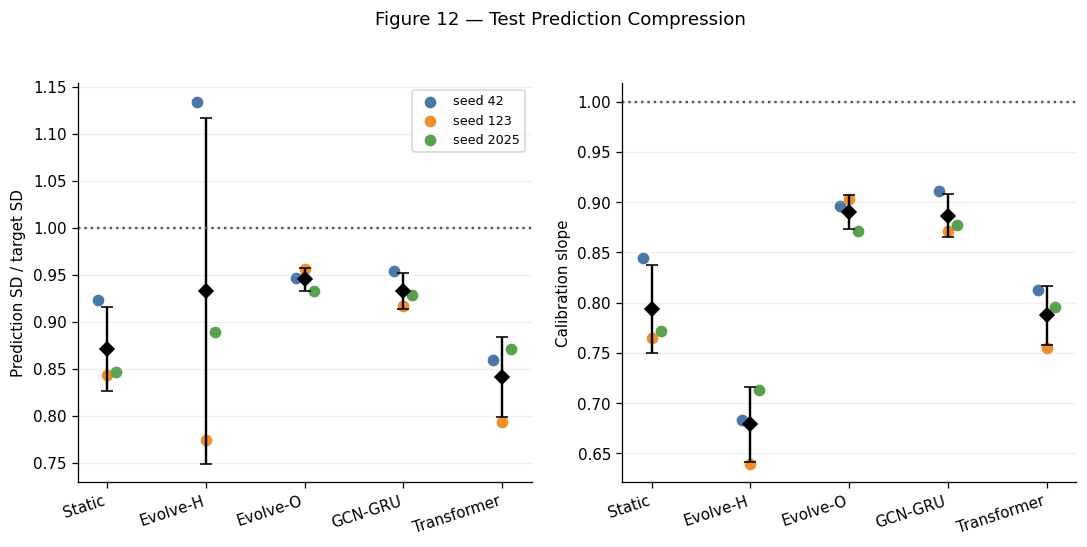

In [17]:
fig12=compression(test,'Figure 12 — Test Prediction Compression','fig12_test_compression.png')

O and GRU are closest to ideal across combined test diagnostics. Compression persists because mean slopes remain below one.

# 22 — Validation versus test

In [18]:
vc=post['validation_directions']; tc=post['test_directions']; labels={'EvolveGCN-H - Static GCN':'H vs Static','EvolveGCN-O - Static GCN':'O vs Static','GCN-GRU - Static GCN':'GRU vs Static','GCN-Transformer - Static GCN':'Transformer vs Static','EvolveGCN-O - EvolveGCN-H':'O vs H','GCN-Transformer - GCN-GRU':'Transformer vs GRU'}; table07=pd.DataFrame([[v,vc[k],tc[k],'Same classification' if vc[k]==tc[k] else 'Classification changed'] for k,v in labels.items()],columns=['Comparison','Validation classification','Test classification','Interpretation']); tabsave(table07,7,'validation_vs_test'); display(table07.style.hide(axis='index'))

Comparison,Validation classification,Test classification,Interpretation
H vs Static,ROBUST DEGRADATION,ROBUST DEGRADATION,Same classification
O vs Static,SEED-DEPENDENT,ROBUST IMPROVEMENT,Classification changed
GRU vs Static,ROBUST IMPROVEMENT,ROBUST IMPROVEMENT,Same classification
Transformer vs Static,ROBUST IMPROVEMENT,SEED-DEPENDENT,Classification changed
O vs H,ROBUST IMPROVEMENT,ROBUST IMPROVEMENT,Same classification
Transformer vs GRU,ROBUST DEGRADATION,ROBUST DEGRADATION,Same classification


**PARTIALLY CONFIRMS.** Two secondary classifications change, but the central conclusion is strongly confirmed: GCN-GRU remains the lowest-MAE model at every test seed.

# 23 — Hypothesis, evidence, and conclusion

In [19]:
table08=pd.DataFrame([['Temporal information can improve over Static','GCN-GRU wins all validation/test seeds','SUPPORTED FOR GCN-GRU'],['EvolveGCN-H is specifically weak','O robustly outperforms H','SUPPORTED'],['Recurrent graph-level aggregation is effective','GRU has lowest validation/test MAE','SUPPORTED'],['Self-attention is superior to recurrence','Transformer loses to GRU at every seed','NOT SUPPORTED'],['Richer temporal modeling removes compression','GRU/O improve diagnostics; slopes remain below 1','PARTIALLY SUPPORTED / NOT FULLY RESOLVED']],columns=['Hypothesis','Evidence','Conclusion']); tabsave(table08,8,'hypotheses'); display(table08.style.hide(axis='index'))

Hypothesis,Evidence,Conclusion
Temporal information can improve over Static,GCN-GRU wins all validation/test seeds,SUPPORTED FOR GCN-GRU
EvolveGCN-H is specifically weak,O robustly outperforms H,SUPPORTED
Recurrent graph-level aggregation is effective,GRU has lowest validation/test MAE,SUPPORTED
Self-attention is superior to recurrence,Transformer loses to GRU at every seed,NOT SUPPORTED
Richer temporal modeling removes compression,GRU/O improve diagnostics; slopes remain below 1,PARTIALLY SUPPORTED / NOT FULLY RESOLVED


# 24 — Limitations
1. Three screening seeds; summaries are descriptive. 2. Models are not parameter matched. 3. Static sees one snapshot and temporal models five. 4. H is much larger. 5. No extensive hyperparameter sweep. 6. Results are CAMELS-SIMBA U1000/Top1500/raw7/k8-specific. 7. Raw-coordinate symmetry sensitivity remains. 8. Snapshot-specific signal is unidentified. 9. GRU is not claimed universally superior.

# 25 — Final scientific conclusion
Temporal information is useful in this regime, but its benefit depends strongly on representation and aggregation. EvolveGCN-H degraded performance, while O substantially improved the family result. GCN-GRU gave the clearest gain, winning all matched validation seeds and retaining that advantage on held-out test. Transformer did not match GRU. GRU and O improved distribution recovery relative to Static, although compression remained. These results support the tested recurrent mechanism without implying causality or universal superiority.

# 26 — Final verdict and reproducibility closure

In [20]:
card=pd.DataFrame([['Temporal study','CLOSED'],['Validation-selected architecture','GCN-GRU'],['Validation MAE','0.02806 ± 0.00200'],['Held-out test MAE','0.02939 ± 0.00048'],['Seed consistency','3/3 validation wins; 3/3 test wins vs Static'],['Next direction','Later controlled follow-up only']],columns=['Item','Verdict']); display(card.style.hide(axis='index'))
expected=[.02806488502306569,.029392737357770624,.038022502704902934,.03788661949373596]; observed=[vs.query("model=='GCN-GRU'").mae_mean.iloc[0],ts.query("model=='GCN-GRU'").mae_mean.iloc[0],vs.query("model=='Static GCN'").mae_mean.iloc[0],ts.query("model=='Static GCN'").mae_mean.iloc[0]]; assert np.allclose(expected,observed,atol=1e-12,rtol=0)
assert all(test.query("model=='GCN-GRU'").set_index('seed').mae<test.query("model=='Static GCN'").set_index('seed').mae)
figures=list(OUT.glob('fig*.png')); tables=list(OUT.glob('table*.csv')); supplements=list(OUT.glob('supp*.png')); assert len(figures)==12 and len(tables)==8 and len(supplements)==10 and all(p.stat().st_size for p in figures+tables+supplements)
closure=pd.DataFrame([['Frozen sources','PASS','10 tabular + 7 registry'],['Coverage','PASS','5 models × 3 seeds'],['Predictions','PASS','201 rows per model/seed'],['Firewall','PASS','validation decision precedes test'],['Outputs','PASS','12 figures / 8 tables / 10 supplements'],['Training or inference','NO','artifact-only presentation']],columns=['Closure item','Status','Evidence']); display(closure.style.hide(axis='index')); print('NOTEBOOK 16 TEMPORAL STUDY CLOSED — READY FOR REVIEW')

Item,Verdict
Temporal study,CLOSED
Validation-selected architecture,GCN-GRU
Validation MAE,0.02806 ± 0.00200
Held-out test MAE,0.02939 ± 0.00048
Seed consistency,3/3 validation wins; 3/3 test wins vs Static
Next direction,Later controlled follow-up only


Closure item,Status,Evidence
Frozen sources,PASS,10 tabular + 7 registry
Coverage,PASS,5 models × 3 seeds
Predictions,PASS,201 rows per model/seed
Firewall,PASS,validation decision precedes test
Outputs,PASS,12 figures / 8 tables / 10 supplements
Training or inference,NO,artifact-only presentation


NOTEBOOK 16 TEMPORAL STUDY CLOSED — READY FOR REVIEW
